## Fuzzy C-Means 

#### Prince Ikpabi, Hildebrand Department of Petroleum and Geosystems Engineering, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/prince-ikpabi-ds/)

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences




_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin


### Executive Summary

In many oil and gas quantities, such as RPM trends and vibration severity states during drilling, or permeability-porosity clusters and facies classification in reservoir engineering, samples are transitional, changing gradually, and do not fit neatly into one category, revealing a gap in traditional hard clustering methods that are mutually exclusive and force rigid boundaries. Fuzzy C-Means (FCM) addresses this by allowing data points to belong to multiple clusters with varying degrees of membership, capturing the uncertainty and transitional nature in complex systems. By minimizing an objective function based on distance and membership weights, FCM iteratively adjusts cluster centers until stability is achieved. This approach revealed meaningful patterns and transitional states that hard clustering would have missed. I recommend careful selection of the fuzziness parameter (m) and number of clusters, along with visualization of membership values to interpret overlaps and ensure the results reflect true underlying relationships in the data.

### Importing Packages  

There are two ways to import the Fuzzy C-Means. 

+ Option A (scikit-fuzzy functional API) — flexible, interpretable, and detailed (exposes memberships directly). 
+ Option B (fcmeans sklearn-style API) — easy to integrate and works faster than option A on large datasets.

Both options produce similar results. We will go with Option A in this workflow.

In [1]:
# code to install scikit-fuzzy if not already installed
!pip install scikit-fuzzy                              

### We will go ahead to import other important libraries

In [2]:
import pandas as pd                                                   # DataFrames for tabular data
import numpy as np                                                    # NumPy for numerical operations and array handling
import matplotlib.pyplot as plt                                       # Matplotlib for 2D plotting
import ipywidgets as widgets                                          # Interactive HTML widgets for Jupyter
from ipywidgets import interact                                       # Interact function for creating interactive widgets
from functools import lru_cache                                       # Caches function results to speed up repeated calls with the same parameters
import seaborn as sns                                                 # Data visualization
from matplotlib.colors import LinearSegmentedColormap                 # Importing specific functions from Matplotlib
from sklearn import metrics                                           # Evaluating cluster performance
import skfuzzy as fuzz                                               # Fuzzy C-Means clustering
plt.rc('axes', axisbelow=True)                                        # Plot all grids below the plot elements
ignore_warnings = True                                                # ignore warnings
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno                                                  # color map
seed = 42                                                              # random number seed 

This workflow uses some visualization function codes from GeostatsGuy github repository. The refered workflow for visualiztions can be viewed here:  [GeostatsGuy Advanced Clustering](https://github.com/GeostatsGuy/PythonNumericalDemos/blob/master/SubsurfaceDataAnalytics_advanced_clustering.ipynb)

### Functions
The provided lines of code below include functions for Fuzzy clustering implementation, visualization, and hyperparameter tuning. The **create_cmap**, **arrange_plot**, **visualize_fcm_overview_m** and **visualize_fcm_memberships_m** functions aid visualization. The **fcm_fit_predict** function runs Fuzzy C-Means on the data and returns key values describing the clusters. The **xie_beni_index** and **partition_entropy** functions are useful for hyperparametric tuning of the fuzzy c-means algorithm. These functions collectively offer tools for Fuzzy C-Means clustering with adequate visualization. There is also the **_fit_cached** function, which serves as a wrapper to cache FCM fits so the slider result is quickly updated.

In [3]:
# ---------------------------
# visualization helper function
# ---------------------------
def create_cmap(n_colors, palette):
    a = {}
    palette = sns.color_palette(palette=palette, n_colors=n_colors, desat=0.8, as_cmap=False)
    for i in range(0, n_colors):
        color = palette[i:i+1][0]
        count = n_colors/n_colors + i
        a.update({count - 1: color})                               # From GeostatsGuy workflows
    return a

# ---------------------------
# visualization helper function
# ---------------------------
def arrange_plot(title, xlabel, ylabel, xlim=None, ylim=None, size=None):
    if size == 'Small':
        plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel)
    else:
        plt.title(title, fontsize=16); plt.xlabel(xlabel, fontsize=14); plt.ylabel(ylabel, fontsize=14)
    plt.xlim(xlim); plt.ylim(ylim); plt.grid(alpha=0.8)
    plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.2)  # From GeostatsGuy workflows

# ---------------------------
# speed up function
# --------------------------
def _fit_cached(m_val, k_val):
    cntr, u, labels, fpc = fcm_fit_predict(
        X2, n_clusters=int(k_val), m=float(m_val),
        error=1e-5, maxiter=1000, seed=42, scale=False
    )
    return cntr, u, labels, fpc

# ---------------------------
# visualization helper function
# ---------------------------
def visualize_fcm_overview_m(m=2.0, k=3):
    cntr, u, labels, fpc = _fit_cached(m, k)
    conf = u.max(axis=0)                    # confidence (0..1)
    palette = sns.color_palette('tab10', k)

    plt.figure(figsize=(7,5))
    for c in range(k):
        mask = (labels == c)
        plt.scatter(
            X2[mask,0], X2[mask,1],
            s=18, alpha=conf[mask], c=[palette[c]],
            edgecolor='black', linewidth=0.2, label=f'C{c}'
        )
    plt.scatter(cntr[:,0], cntr[:,1], s=180, c='white', edgecolor='black',
                marker='*', label='centers', zorder=5)
    plt.title(f'FCM overview (k={k}, m={m:.2f}) — alpha = confidence | FPC={fpc:.3f}')
    plt.xlabel('Porosity'); plt.ylabel('AI'); plt.grid(alpha=0.3); plt.legend(ncols=min(k,4))
    plt.show()

# ---------------------------
# visualization helper function
# ---------------------------
def visualize_fcm_memberships_m(m=2.0, k=3):
    """
    The plots from this function show the membership intensity of each point to each cluster
    """
    _, u, _, fpc = _fit_cached(m, k)
    n_cols = min(k, 3)
    n_rows = int(np.ceil(k / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.ravel(axes) if k > 1 else [axes]

    for i in range(k):
        sc = axes[i].scatter(
            X2[:,0], X2[:,1],
            c=u[i], s=20, cmap='viridis', vmin=0.0, vmax=1.0,
            edgecolor='none'
        )
        axes[i].set_title(f'Membership to C{i}  (k={k}, m={m:.2f})')
        axes[i].set_xlabel('Porosity'); axes[i].set_ylabel('AI'); axes[i].grid(alpha=0.3)
        cb = plt.colorbar(sc, ax=axes[i]); cb.set_label('membership')

    for ax in axes[k:]:
        ax.remove()
    fig.suptitle(f'FCM membership maps | FPC={fpc:.3f}', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


# ---------------------------
# FCM implementation function
# ---------------------------
def fcm_fit_predict(X, n_clusters, m=2.0, error=1e-5, maxiter=1000, seed=42, scale=False, return_scaler=False):
    """
    Runs Fuzzy C-Means on X and returns (centers, memberships u, hard_labels, fpc [, scaler]).
    - X: (n_samples, n_features)
    - hard_labels: argmax over memberships (n_samples,)
    """
    if scale:
        scaler = StandardScaler()
        X_s = scaler.fit_transform(X)
    else:
        X_s = np.asarray(X, dtype=float)              # In this workflow, our features will be normalized, so we won't have to scale.

    
    data_T = X_s.T                                    # scikit-fuzzy expects data as (features, samples), so we transpose.

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data=data_T,
        c=n_clusters,
        m=m,
        error=error,
        maxiter=maxiter,
        init=None,
        seed=seed
    )
    # we use hard labels for metrics/plots
    labels = u.argmax(axis=0)

    if return_scaler and scale:
        return cntr, u, labels, fpc, scaler
    return cntr, u, labels, fpc


# ---------------------------
#  hyperparameter tuning function
# ---------------------------   
def xie_beni_index(X, u, centers, m=2.0):
    """
    Computes the Xie–Beni (XB) validity index for Fuzzy C-Means.
    
    Parameters:
        X       : array, shape (n_samples, n_features)
        u       : membership matrix, shape (n_clusters, n_samples)
        centers : cluster centers, shape (n_clusters, n_features)
        m       : fuzziness parameter

    Returns:
        XB index (float) — lower values indicate better clustering.
    """
    X = np.asarray(X, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(centers, dtype=float)

    n_clusters = v.shape[0]
    n_samples = X.shape[0]

    # We compute squared distances: dist_sq[j,i] = ||x_i - v_j||^2
    dist_sq = np.zeros((n_clusters, n_samples))
    for j in range(n_clusters):
        dist_sq[j] = np.sum((X - v[j])**2, axis=1)

    # numerator
    numerator = np.sum((u**m) * dist_sq)

    # denominator: N * min_{j != k} ||v_j - v_k||^2
    min_center_dist = np.inf
    for j in range(n_clusters):
        for k in range(j+1, n_clusters):
            d = np.sum((v[j] - v[k])**2)
            if d < min_center_dist:
                min_center_dist = d

    denominator = n_samples * min_center_dist
    return numerator / denominator

# ---------------------------
#  hyperparameter tuning function
# ---------------------------   
def partition_entropy(u):
    """
    Computes the Partition Entropy (PE) for fuzzy clustering.

    Parameters:
        u : membership matrix (n_clusters, n_samples)

    Returns:
        PE value (float) — lower values indicate crisper membership structure.
    """
    u = np.asarray(u, dtype=float)
    eps = 1e-12
    N = u.shape[1]

    PE = -np.sum(u * np.log(u + eps)) / N
    return PE



### Loading the Data

The dataset is imported from the github repository of Prof. Micheal Pyrcz, Data can be found in the link:

(
(https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/nonlinear_facies_v2.csv)

The following features are used in this workflow.

* **Porosity** - This is the ratio of the void volume to the ratio of the total volume of a porous medium. Its unit is percentage.
* **acoustic impedance** - This is a measure of a rock's resistance to the passage of acoustic waves ($\frac{kg}{m^3} \cdot \frac{m}{s} \cdot 10^3$). 
* **Facies** - This is a distinctive rock unit or set of characteristics within a rock unit that reflects specific sedimentary or environmental conditions during its formation (unitless).
* **Normalization** - This is important because data uses Euclidean distance to perform the clustering process; therefore, porosity and acoustic impedance data are normalized.

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/nonlinear_facies_v2.csv')

pormin = df['Por'].min(); pormax = df['Por'].max()
AImin = df['AI'].min(); AImax = df['AI'].max()

df['Norm_Por'] = (df['Por']-pormin)/(pormax - pormin)
df['Norm_AI'] = (df['AI']-AImin)/(AImax - AImin)

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1800.0,205.055556,137.362381,0.0,89.750000,179.500000,316.000000,499.0
Por,1800.0,17.122778,4.778704,0.0,14.663434,17.674606,20.361860,30.0
AI,1800.0,625.522917,247.547997,10.0,518.076017,683.865824,783.315226,1200.0
Facies,1800.0,1.666667,0.816723,1.0,1.000000,1.000000,2.000000,3.0
Norm_Por,1800.0,0.570759,0.159290,0.0,0.488781,0.589154,0.678729,1.0
Norm_AI,1800.0,0.517246,0.208024,0.0,0.426955,0.566274,0.649845,1.0


### Visualizing the dataset

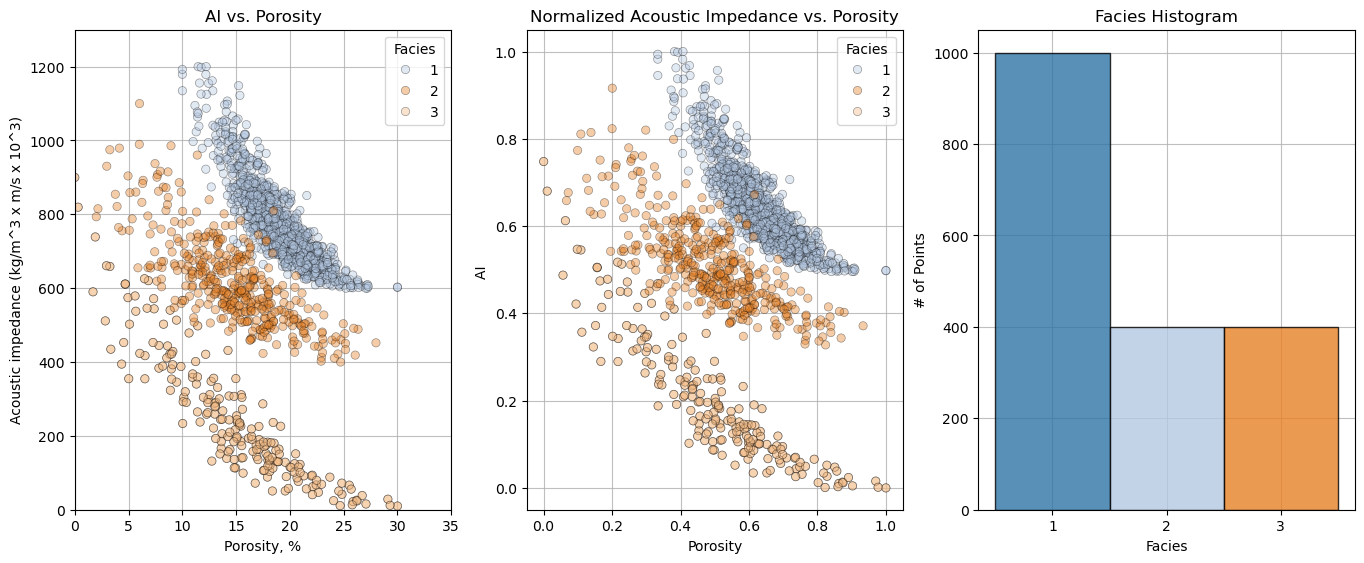

In [5]:
cmap = create_cmap(4,'tab20')

# Plotting the data
plt.subplot(131)
sns.scatterplot(x='Por', y='AI', hue='Facies', data=df, alpha=0.4, palette=cmap, edgecolor="black")
arrange_plot('AI vs. Porosity', 'Porosity, %', 'Acoustic impedance (kg/m^3 x m/s x 10^3)', [0, 35], [0, 1300], size='Small')
plt.subplot(132)
sns.scatterplot(x='Norm_Por', y='Norm_AI', hue='Facies', data=df, alpha=0.4, palette=cmap, edgecolor="black")
arrange_plot('Normalized Acoustic Impedance vs. Porosity', 'Porosity', 'AI ', xlim=None, ylim=None, size='Small')
plt.subplot(133)
N, bins, patches  = plt.hist(df['Facies'],alpha=0.8,edgecolor="black",bins=[0.5,1.5,2.5,3.5],range=[0.5,2.5])
for i in range(0,len(cmap)-1):
    patches[i].set_facecolor(cmap[i][:])
plt.xticks([1,2,3]);arrange_plot('Facies Histogram','Facies','# of Points',size='Small')

### Workflow Overview


**Step 1 - Data Preparation** <br>
This step entails getting the values of the features of interest, as X2, the global name of our dataframe used in defining the functions

**Step 2 - Implementation and Visualization of Fuzzy C-Means** <br>
This step implements the Fuzzy C-Means clustering process and gives an interactive visualization of the result.

**Step 3 - Tuning of Fuzzy C-Means Hyperparameters** <br>
We try to tune the hyperparameters using the **Partition Entropy**, and the **Xie Beni Index**.



### 1. Prepare the data


In [6]:
# --- prep: 2D features
X2 = df[['Norm_Por','Norm_AI']].values

### 2. Implementation of Fuzzy C-Means

The **Fuzzy C-Means (FCM)** algorithm extends k-Means by allowing each sample to belong to multiple clusters with different degrees of membership. Unlike K-Means, which assigns each point to exactly one cluster, FCM uses *soft* memberships and is therefore better at capturing transitional or ambiguous samples.

**Distance Metric Used in FCM**  
Standard FCM is defined using the **squared Euclidean distance**, which is built directly into its objective function:

$$
d_{ij} = \lVert x_i - v_j \rVert^2
$$

where  
- \( x_i \) is a data point,  
- \( v_j \) is the center of cluster \( j \).

The Euclidean norm is:

$$
\lVert x_i - v_j \rVert =
\sqrt{
\sum_{p=1}^{P} (x_{ip} - v_{jp})^2
}
$$


---

In this work, we use **3 clusters**, guided by the ocular inspection of the previous plot of the data, but the main hyperparameters of interest are the **number of clusters (c)** and the **fuzziness parameter (m)**.

1. **Number of Clusters (c — also shown as k):**  
   Defines how many cluster centers are formed.

2. **Fuzziness Parameter (m):**  
   Controls how soft or crisp (definite) the memberships are.  
   When \( m = 1 \), FCM behaves like K-Means (hard clustering).  
   As \( m \) increases, boundaries soften and transitional samples become more visible.

   The membership update equation is:

   $$
   u_{ij} =
   \left[
   \sum_{k=1}^{C}
   \left(
   \frac{\lVert x_i - v_j \rVert}
        {\lVert x_i - v_k \rVert}
   \right)^{\frac{2}{m-1}}
   \right]^{-1}
   $$

   In practice, supported by [Bezdek (1973)](https://doi.org/10.1080/01969727308546047),  
   **\( m = 2 \)** is widely used because it produces stable, interpretable memberships without making clusters too fuzzy.

3. **Convergence Threshold (ε):**  
   The algorithm stops when changes in cluster centers or memberships fall below ε.

4. **Maximum Iterations (max_iter):**  
   Ensures the algorithm stops even if convergence is slow.

---

### Output Metrics
FCM returns cluster centers, membership maps, and the **Fuzzy Partition Coefficient (FPC)**:

$$
\mathrm{FPC} =
\frac{1}{N}
\sum_{i=1}^{N}
\sum_{j=1}^{C}
u_{ij}^{2}
$$

Higher FPC values (closer to 1) indicate more crisp or definite clusters, while lower values (closer to 1/**c** ) indicate stronger overlap.


### We implement FCM and visualize the results using our already defined functions

In [7]:
# We implement FCM and visualize the result

# --- simple UI
m_slider = widgets.FloatSlider(value=1.8, min=0.6, max=3.0, step=0.05, description='m')
k_slider = widgets.IntSlider(value=3, min=2, max=8, step=1, description='k')
interact(visualize_fcm_overview_m, m=m_slider, k=k_slider);


interactive(children=(FloatSlider(value=1.8, description='m', max=3.0, min=0.6, step=0.05), IntSlider(value=3,…

### Let's visualize the membership maps of each cluster

In [8]:
interact(visualize_fcm_memberships_m, m=m_slider, k=k_slider);

interactive(children=(FloatSlider(value=1.8, description='m', max=3.0, min=0.6, step=0.05), IntSlider(value=3,…

By varying the fuzziness parameter \( m \), we can observe how membership patterns and transitional zones change.  
This plot allows us to select values of \( m \) and \( c \) that produce meaningful cluster structure while still revealing transitional behavior within the dataset.


In our result, at k=3, m=2, for which **FPC ≈ 0.66**, the clusters are well-formed while still showing meaningful transition zones, as visible in the membership plots.

### 3. Tuning of Fuzzy C-Means Hyperparameters

Unlike K-Means, the **Silhouette Score** cannot be used to evaluate FCM because FCM is designed to reveal *overlap* and *transitional samples*, not to maximize separation. Instead, fuzzy clustering is tuned using indices that directly measure the *degree of fuzziness* and the *quality of the partition*.

The main fuzzy validity indices used in this workflow will be

1. **Partition Entropy (PE):**  
   Measures the overall uncertainty of the clustering.  
   Lower PE indicates clearer membership structure, while higher PE reflects more transitional behavior.


2. **Xie–Beni Index (XB):**  
   Evaluates clustering quality by balancing compactness and cluster separation:

   $$
   \mathrm{XB} =
   \frac{
      \sum_{i=1}^{N} \sum_{j=1}^{C} u_{ij}^{m} \, \lVert x_i - v_j \rVert^{2}
   }{
      N \cdot \min_{j \ne k} \lVert v_j - v_k \rVert^{2}
   }
   $$

   Lower XB values indicate better fuzzy partitions.



### Proceeding with the hyperparameter tuning

To tune the FCM hyperparameters, we perform a grid search over a range of clusters \(c\) and fuzziness \(m\). In the next lines of code below, for each \((m, c)\) pair, the model was fitted and three indices were computed: the Xie–Beni index (XB), the Partition Entropy (PE), and the Fuzzy Partition Coefficient (FPC). XB and PE were then plotted as heatmaps over the \((m, c)\) grid. The **optimal number of clusters** was chosen by selecting the value of \(c\) that minimized XB on average, while the **optimal fuzziness** was selected as the value of \(m\) that minimized PE. 


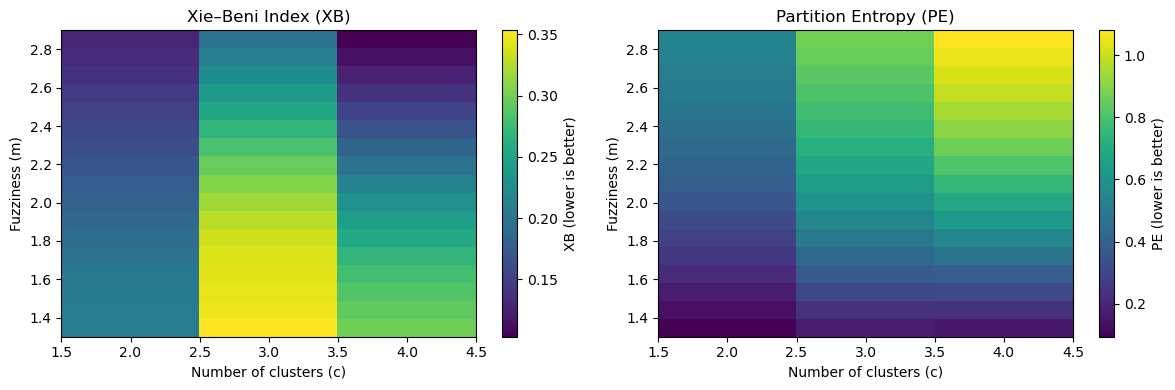

In [9]:
# Ranges to explore
m_values = np.arange(1.3, 3.0, 0.1)     # fuzziness parameter
c_values = np.arange(2, 5, 1)           # number of clusters

xb_grid = np.zeros((len(m_values), len(c_values)))
pe_grid = np.zeros((len(m_values), len(c_values)))
fpc_grid = np.zeros((len(m_values), len(c_values)))

for i, m in enumerate(m_values):
    for j, c in enumerate(c_values):
        cntr, u, labels, fpc = fcm_fit_predict(
            X2,
            n_clusters=int(c),
            m=float(m),
            error=1e-5,
            maxiter=1000,
            seed=42,
            scale=False   # Our X2 features are normalized already
        )
        xb_grid[i, j]  = xie_beni_index(X2, u, cntr, m=float(m))
        pe_grid[i, j]  = partition_entropy(u)
        fpc_grid[i, j] = fpc


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XB heatmap (lower is better)
im0 = axes[0].imshow(
    xb_grid,
    aspect='auto',
    origin='lower',
    extent=[c_values[0] - 0.5, c_values[-1] + 0.5, m_values[0], m_values[-1]]
)
axes[0].set_title("Xie–Beni Index (XB)")
axes[0].set_xlabel("Number of clusters (c)")
axes[0].set_ylabel("Fuzziness (m)")
fig.colorbar(im0, ax=axes[0], label="XB (lower is better)")

# PE heatmap (lower is better)
im1 = axes[1].imshow(
    pe_grid,
    aspect='auto',
    origin='lower',
    extent=[c_values[0] - 0.5, c_values[-1] + 0.5, m_values[0], m_values[-1]]
)
axes[1].set_title("Partition Entropy (PE)")
axes[1].set_xlabel("Number of clusters (c)")
axes[1].set_ylabel("Fuzziness (m)")
fig.colorbar(im1, ax=axes[1], label="PE (lower is better)")

plt.tight_layout()
plt.show()

### Let's extract the best values of hyperparameter c and m.

We can get the best number of clusters from Xie-Beni Index by averaging over "m" 

In [10]:
# We average XB index over m for each c, then pick the minimum
xb_mean_over_m = xb_grid.mean(axis=0)  # shape = (len(c_values),)
best_c = c_values[np.argmin(xb_mean_over_m)]
print("Best c (from XB) =", best_c)


Best c (from XB) = 2


The best number of clusters from the Xie-Beni Index is 2.  
We will attempt to extract the best m from PE by averaging over "c"

In [11]:
pe_mean_over_c = xb_grid.mean(axis=1)  # shape = (len(m_values),)
best_m = m_values[np.argmin(pe_mean_over_c)]
print("Best m (from PE) =", best_m)

Best m (from PE) = 2.9000000000000012


The best value of m from PE found was found to equal 2.90

Alternatively, we can choose to combine both Xie-Beni and Partition Entropy to get the best values of c and m.

In [12]:
idx = np.unravel_index(np.argmin(xb_grid), xb_grid.shape)
best_m_joint = m_values[idx[0]]
best_c_joint = c_values[idx[1]]
print("Joint best (m, c) from XB =", best_m_joint, best_c_joint)


Joint best (m, c) from XB = 2.9000000000000012 4


**The best values of m and c, from the combination are 2.9, 4, respectively.**  
We will refit the FCM using these optimum values and make a visualization of the resulting clusters.

In [13]:
cntr_best, u_best, labels_best, fpc_best = fcm_fit_predict(
    X2, n_clusters=int(best_c_joint), m=float(best_m_joint), scale=False
)

interact(visualize_fcm_overview_m, m=best_m_joint, k=best_c_joint);     #Visualize

interactive(children=(FloatSlider(value=2.9000000000000012, description='m', max=8.700000000000003, min=-2.900…

Let's visualize the membership maps

In [14]:
interact(visualize_fcm_memberships_m, m=best_m_joint, k=best_c_joint);

interactive(children=(FloatSlider(value=2.9000000000000012, description='m', max=8.700000000000003, min=-2.900…

### Result of hyperparameter tuning

Using the Xie–Beni (XB) and Partition Entropy (PE) indices, the optimal parameters for the Fuzzy C-Means algorithm were found to be **4 clusters** and a **fuzziness value of m = 2.90**. The resulting clustering structure captures four distinct groups in the Porosity–AI space, each with well-defined cores and smoothly varying transition zones.

The **FPC value of 0.425** indicates a moderately fuzzy partition. Overall, these plots show which samples are strongly associated with a cluster and which sit in intermediate regions between clusters. 


### Results

#### Summary of the Fuzzy C-Means Workflow

The Fuzzy C-Means (FCM) algorithm was applied to identify clusters within the normalized Porosity–AI dataset. Unlike K-Means, which forces each point into a single cluster, FCM assigns a membership value to every cluster, allowing the model to capture transitional samples and gradual changes in the properties.

My workflow involved three key stages:

1. **Data Preparation** 
    Porosity-AI features were used in this work, derived from one of the datasets used in the course.

2. **Model Construction and Visualization:**  
   FCM was implemented using the squared Euclidean distance metric and the standard objective function. Initial experiments used 3 clusters for visualization and parameter exploration.

   Cluster overview plots and membership intensity maps were generated to evaluate the behavior of the clustering under different fuzziness values \(m\). These visualizations highlighted regions of high certainty as well as zones where samples exhibit mixed characteristics.

3. **Model Tuning:**  
   A grid search over \((m, c)\) was conducted using the Xie–Beni Index (XB) and Partition Entropy (PE).  
   - In one step, **XB** was used to determine the optimal number of clusters \(c\).  
   - In another, **PE** was used to determine the best fuzziness parameter \(m\).
   - However, we combined both **XB** and **PE** in the last step to determine the optimal hyperparameters.
   

The resulting optimal model (k = 4, m = 2.90) revealed clear cluster structures while trying to preserve the continuity in the data. I would recommend fuzzy set for clustering of known transitional quantities in the industry, as it gives a more realistic picture of how samples relate. 

### About Prince B. Ikpabi

*Bsc in Petroleum Engineering, University of Ibadan 2024*<br>
*Ph.D. student at Hilderbrand Department of Petroleum and Geosystems Engineering, University of Texas at Austin*<br>

**Research Interests:**
* Drilling Automation
* Scientific ML 
* Data Science and AI 
* Reservoir Engineering
  

Feel free to contact me about this workflow, or my research topic of interest.

Sincerely,<br>
*Prince Ikpabi*

___________________

### Work Supervised by:

#### Michael Pyrcz, Associate Professor, University of Texas at Austin 
*Novel Data Analytics, Geostatistics and Machine Learning Subsurface Solutions*

With over 17 years of experience in subsurface consulting, research and development, Michael has returned to academia driven by his passion for teaching and enthusiasm for enhancing engineers' and geoscientists' impact in subsurface resource development. 

For more about Michael check out these links:

#### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)